# Simulation SVD -- anneau de gaussiennes radiales (choroide synthetique)

Visualise les resultats de `Astronauts/simulate_svd_radial_gaussians.py` : un
anneau de gaussiennes (choroide synthetique) qui "respire" radialement selon
un chirp 1.0 -> 1.3 Hz, mesure via la chaine complete du package
(`PixelTraceSource` -> `DecomposedTraceSource(method="svd")` ->
`LombScargleRateEstimator` -> `OptimizedSpectralCombination` ->
`HilbertPhaseEstimator`), en balayant jitter de recalage residuel (x commun,
y par A-scan) et bruit d'image.

Deux niveaux de lecture :

1. **Vue d'ensemble du balayage** (`summary.csv`) : courbes de detectabilite
   pour les balayages 1D (phase A -- amplitude, bruit, jitter_x, jitter_y
   independamment) et grilles combinees (phase B -- jitter_x x jitter_y x
   bruit, a deux amplitudes).
2. **Vue detaillee d'un run** (`.npz`) : vecteurs singuliers gauche/droit
   (U, V) et valeurs singulieres (S), signal agrege vs verite terrain, phase
   de Hilbert vs frequence instantanee vraie -- et, a la demande, le cube
   synthetique **regenere** (aucun cube n'est sauvegarde sur disque : chaque
   run est entierement determine par ses parametres + graine).

Change simplement `RUN_TAG` dans la section "regarder un run individuel"
pour explorer un autre point du balayage.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ASTRONAUTS_DIR = Path("../Astronauts").resolve()
sys.path.insert(0, str(ASTRONAUTS_DIR))
import simulate_svd_radial_gaussians as sim  # noqa: E402

from ocularrigidity.motion.pulsation.rate import lomb_scargle_power

SUMMARY_CSV = sim.SUMMARY_CSV

if SUMMARY_CSV.exists():
    df = pd.read_csv(SUMMARY_CSV)
    print(f"{len(df)} runs charges depuis {SUMMARY_CSV}")
    print(df["phase"].value_counts())
    print(df.tag)
else:
    df = pd.DataFrame()
    print(
        f"{SUMMARY_CSV} n'existe pas encore -- lancez d'abord "
        "`python Astronauts/simulate_svd_radial_gaussians.py`."
    )


c:\Users\transformer\anaconda3\envs\pyOR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0811 13:13:18.383000 234528 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


1015 runs charges depuis E:\SANSORI_simulation_output\svd_radial_gaussians\summary.csv
phase
B_combined     675
A_amplitude    110
A_noise        110
A_jitter_x      60
A_jitter_y      60
Name: count, dtype: int64
0                         amplitude_00.50um_rep0
1                         amplitude_00.50um_rep1
2                         amplitude_00.50um_rep2
3                         amplitude_00.50um_rep3
4                         amplitude_00.50um_rep4
                          ...                   
1010    combined_A08.0_Jx2.00_Jy2.00_N0.82_rep10
1011    combined_A08.0_Jx2.00_Jy2.00_N0.78_rep11
1012    combined_A08.0_Jx2.00_Jy2.00_N0.76_rep12
1013    combined_A08.0_Jx2.00_Jy2.00_N0.91_rep13
1014    combined_A08.0_Jx2.00_Jy2.00_N0.85_rep14
Name: tag, Length: 1015, dtype: str


## A quoi ressemblent les cubes simules

Avant de lire les resultats, regarder les images d'entree. Les `.npz` ne
contiennent pas les cubes (60 Mo chacun) : on les **re-rend** ici a la demande,
avec les memes fonctions que le script (`render_cube` + `add_image_noise`),
donc ce qui s'affiche est exactement ce que la chaine de mesure a vu.

Le rendu coute environ 0.17 s par image, d'ou l'apercu sur un sous-ensemble de
frames (`N_FRAMES_APERCU`). Compter ~40 s pour la cellule entiere.

Deux choses a garder en tete en regardant les images :

* **les pixels ne sont pas carres** : 3.9 um en axial contre 11.4 um en
  lateral. L'anneau, circulaire en microns, apparait donc comme une ellipse
  allongee dans la grille de pixels -- qui est celle sur laquelle la SVD
  travaille.
* **le kymographe est le bon outil** pour voir la pulsation : une coupe fixe
  de l'image tracee en fonction du temps. La respiration radiale y devient un
  motif ondulant, invisible sur les images prises une a une.

calibration reelle : 11.4 um/px lateral, 3.9 um/px axial, 17.9 Hz, 401 frames (22.4 s)
cube complet : 401 x 311 x 121 (60 Mo en float32)
amplitude typique (6 um crete a crete) = 1.54 px en axial, 0.53 px en lateral
  -> le mouvement est SOUS-PIXEL : il ne se voit pas a l'oeil sur une
     image, seulement en modulation d'intensite d'une frame a l'autre.

apercu rendu : (60, 311, 121)  (intensite -0.30 a 8.97)


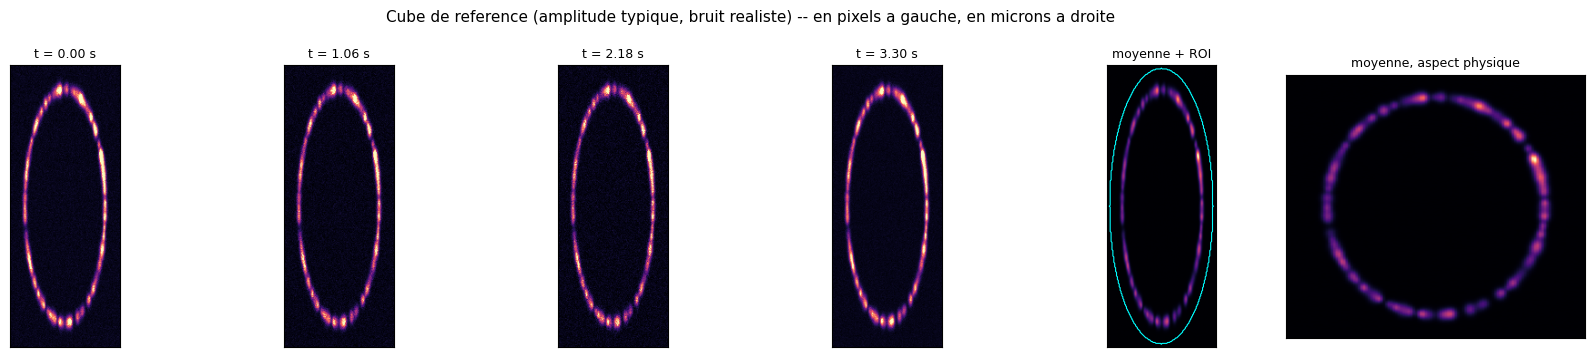

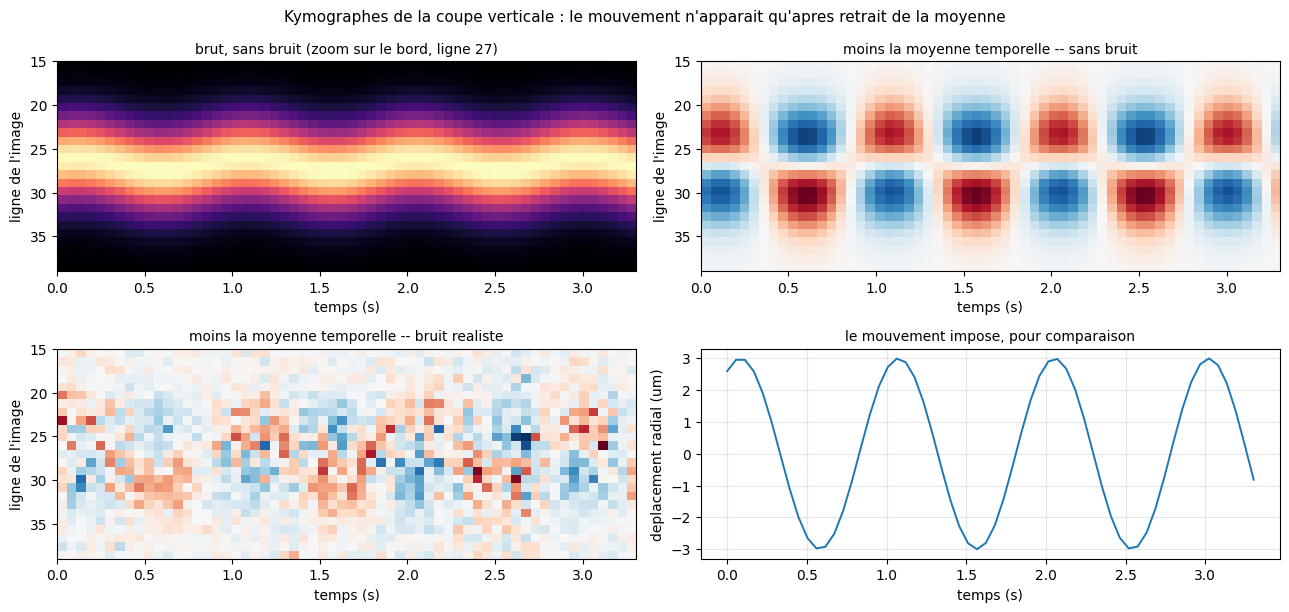

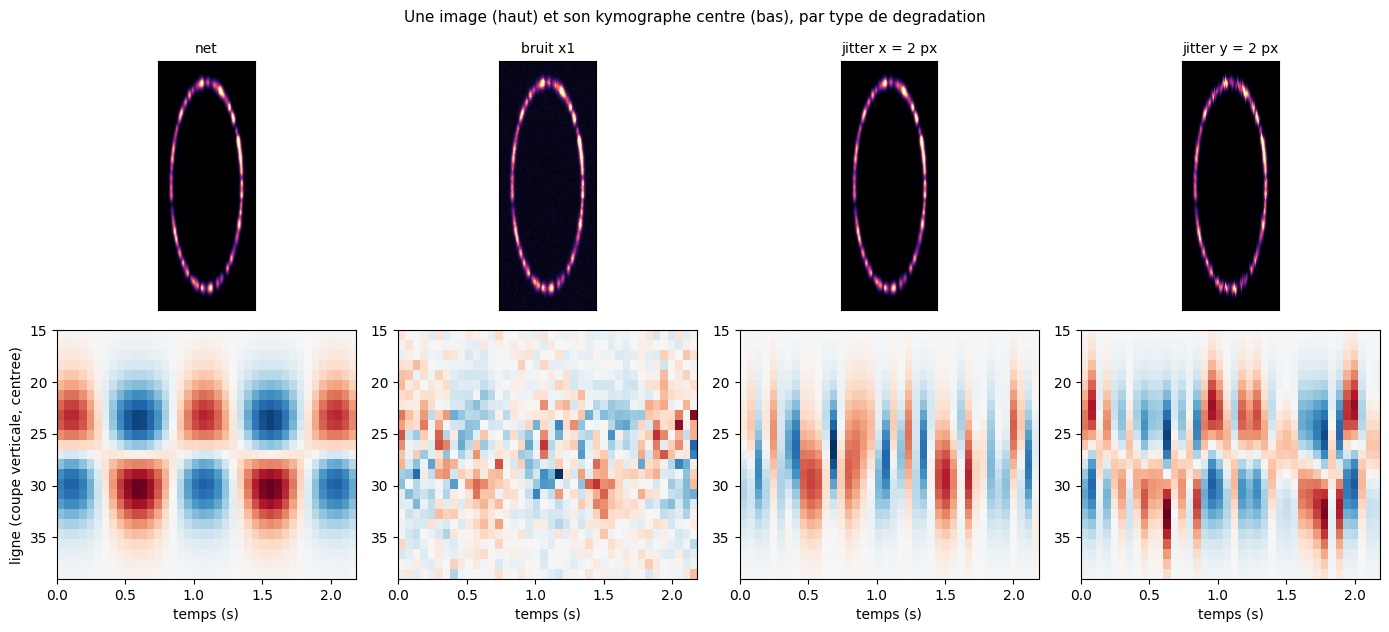


Lecture des kymographes :

* Le kymographe BRUT ne montre rien : a 6 um crete a crete, le bord de
  l'anneau se deplace de 1.54 px seulement. C'est le regime dans lequel
  travaille toute la chaine, et c'est pour cela qu'on ne peut pas juger un run
  a l'oeil sur les images.
* Une fois la moyenne temporelle retiree, le mouvement apparait comme une
  alternance rouge/bleu de part et d'autre du bord -- la signature d'un
  gradient module, exactement le terme dG/dr du developpement de Taylor. Sa
  cadence suit le chirp, comparee au deplacement impose sur le dernier
  panneau.
* Le bruit d'image grise cette alternance sans en deformer la geometrie : il
  s'attaque au contraste, pas a la position.
* Le jitter x (commun a toute l'image) decale l'anneau en bloc ; sur une coupe
  a colonne fixe, cela se lit comme un deplacement vertical parasite du bord.
* Le jitter y (independant par A-scan) hachure le motif : chaque colonne bouge
  pour son compte, ce qui detruit la coherence spatiale entre

In [2]:
# --- Apercu des cubes simules ---------------------------------------------
N_FRAMES_APERCU = 60     # ~3.4 cycles a 1 Hz ; ~0.17 s de rendu par image

CALIB = sim.load_real_calibration()
ANATOMIE = sim.build_ring_anatomy()
FORME = sim.crop_shape(CALIB)            # (H, W)
MASQUE = sim.build_fixed_mask(FORME)
T_COMPLET = np.arange(CALIB.n_frames) / CALIB.fs_hz
DUREE = float(T_COMPLET[-1])
ASPECT_PHYSIQUE = CALIB.scale_y_um / CALIB.scale_x_um   # pour un anneau rond

print(f"calibration reelle : {CALIB.scale_x_um:.1f} um/px lateral, "
      f"{CALIB.scale_y_um:.1f} um/px axial, {CALIB.fs_hz:.1f} Hz, "
      f"{CALIB.n_frames} frames ({DUREE:.1f} s)")
print(f"cube complet : {CALIB.n_frames} x {FORME[0]} x {FORME[1]} "
      f"({CALIB.n_frames * FORME[0] * FORME[1] * 4 / 1e6:.0f} Mo en float32)")
print(f"amplitude typique ({sim.TYPICAL_AMPLITUDE_UM:.0f} um crete a crete) = "
      f"{sim.TYPICAL_AMPLITUDE_UM / CALIB.scale_y_um:.2f} px en axial, "
      f"{sim.TYPICAL_AMPLITUDE_UM / CALIB.scale_x_um:.2f} px en lateral")
print("  -> le mouvement est SOUS-PIXEL : il ne se voit pas a l'oeil sur une")
print("     image, seulement en modulation d'intensite d'une frame a l'autre.")


def rendre_cube(amplitude_um=sim.TYPICAL_AMPLITUDE_UM, jitter_x_px=0.0,
                jitter_y_px=0.0, noise_level=0.0, n_frames=N_FRAMES_APERCU, seed=0):
    """Les `n_frames` premieres images d'un run, sans passer par la mesure.

    `duration_s` reste la duree TOTALE : le chirp est donc identique a celui du
    run complet, on n'en regarde que le debut.
    """
    t = T_COMPLET[:n_frames]
    rng = np.random.default_rng(seed)
    jx, jy = sim.sample_jitter(
        n_frames, FORME[1], sim.JitterParams(jitter_x_px, jitter_y_px), rng
    )
    cube = sim.render_cube(
        ANATOMIE, CALIB, t, DUREE, amplitude_um, jx, jy, FORME
    )
    return sim.add_image_noise(cube, noise_level, rng), t


def kymographe(cube, axe="vertical"):
    """Coupe fixe de l'image, en fonction du temps.

    `vertical` : la colonne centrale (une A-scan) -> (H, T).
    `horizontal` : la ligne centrale -> (W, T).
    """
    H, W = cube.shape[1:]
    if axe == "vertical":
        return cube[:, :, W // 2].T
    return cube[:, H // 2, :].T


# --- 1. Le cube de reference : images, moyenne, ROI ------------------------
cube_ref, t_ref = rendre_cube(noise_level=1.0)
print(f"\napercu rendu : {cube_ref.shape}  (intensite {cube_ref.min():.2f} "
      f"a {cube_ref.max():.2f})")

indices = np.linspace(0, len(t_ref) - 1, 4).astype(int)
fig, axes = plt.subplots(1, 6, figsize=(17, 3.6))
vmax = np.percentile(cube_ref, 99.5)
for ax, i in zip(axes, indices):
    ax.imshow(cube_ref[i], cmap="magma", vmin=0, vmax=vmax)
    ax.set_title(f"t = {t_ref[i]:.2f} s", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
axes[4].imshow(cube_ref.mean(axis=0), cmap="magma")
axes[4].contour(MASQUE, levels=[0.5], colors="cyan", linewidths=0.8)
axes[4].set_title("moyenne + ROI", fontsize=9)
axes[4].set_xticks([]); axes[4].set_yticks([])
axes[5].imshow(cube_ref.mean(axis=0), cmap="magma", aspect=ASPECT_PHYSIQUE)
axes[5].set_title("moyenne, aspect physique", fontsize=9)
axes[5].set_xticks([]); axes[5].set_yticks([])
fig.suptitle("Cube de reference (amplitude typique, bruit realiste) -- "
             "en pixels a gauche, en microns a droite", fontsize=11)
fig.tight_layout()
plt.show()

# --- 2. Kymographes : la pulsation devient visible -------------------------
cube_net, _ = rendre_cube(noise_level=0.0)

# Le deplacement etant sous-pixel, un kymographe brut ne montre RIEN : il faut
# zoomer sur un bord de l'anneau et retirer la moyenne temporelle de chaque
# pixel. Ce qui reste est la modulation d'intensite due au mouvement.
k_net = kymographe(cube_net)
bord = int(np.argmax(k_net.mean(axis=1)))          # la ligne la plus brillante
fenetre = slice(max(bord - 12, 0), bord + 13)
lignes_zoom = np.arange(k_net.shape[0])[fenetre]


def kymo_centre(cube_):
    k = kymographe(cube_)[fenetre]
    return k - k.mean(axis=1, keepdims=True)


fig, axes = plt.subplots(2, 2, figsize=(13, 6.2))
etendue = [t_ref[0], t_ref[-1], lignes_zoom[-1], lignes_zoom[0]]

axes[0, 0].imshow(k_net[fenetre], cmap="magma", aspect="auto", extent=etendue)
axes[0, 0].set_title(f"brut, sans bruit (zoom sur le bord, ligne {bord})", fontsize=10)

for ax, cube_, nom in ((axes[0, 1], cube_net, "sans bruit"),
                       (axes[1, 0], cube_ref, "bruit realiste")):
    kc = kymo_centre(cube_)
    v = np.abs(kc).max()
    ax.imshow(kc, cmap="RdBu_r", aspect="auto", vmin=-v, vmax=v, extent=etendue)
    ax.set_title(f"moins la moyenne temporelle -- {nom}", fontsize=10)

for ax in axes.ravel()[:3]:
    ax.set_xlabel("temps (s)"); ax.set_ylabel("ligne de l'image")

axes[1, 1].plot(t_ref, sim.radial_displacement(t_ref, DUREE,
                                               sim.TYPICAL_AMPLITUDE_UM),
                lw=1.4, color="C0")
axes[1, 1].set_xlabel("temps (s)"); axes[1, 1].set_ylabel("deplacement radial (um)")
axes[1, 1].set_title("le mouvement impose, pour comparaison", fontsize=10)
axes[1, 1].grid(alpha=0.3)

fig.suptitle("Kymographes de la coupe verticale : le mouvement n'apparait "
             "qu'apres retrait de la moyenne", fontsize=11)
fig.tight_layout()
plt.show()

# --- 3. Ce que chaque degradation fait au cube -----------------------------
# Un rendu plus court ici : quatre conditions a comparer.
N_FRAMES_COMPARAISON = 40
conditions = (
    ("net", dict(noise_level=0.0)),
    ("bruit x1", dict(noise_level=1.0)),
    ("jitter x = 2 px", dict(noise_level=0.0, jitter_x_px=2.0)),
    ("jitter y = 2 px", dict(noise_level=0.0, jitter_y_px=2.0)),
)

fig, axes = plt.subplots(2, len(conditions), figsize=(3.5 * len(conditions), 6.4))
for col, (nom, kwargs) in enumerate(conditions):
    cube_c, t_c = rendre_cube(n_frames=N_FRAMES_COMPARAISON, **kwargs)
    axes[0, col].imshow(cube_c[0], cmap="magma", vmin=0,
                        vmax=np.percentile(cube_c, 99.5))
    axes[0, col].set_title(nom, fontsize=10)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    k = kymographe(cube_c)[fenetre]
    k = k - k.mean(axis=1, keepdims=True)
    v = np.abs(k).max()
    axes[1, col].imshow(k, cmap="RdBu_r", aspect="auto", vmin=-v, vmax=v,
                        extent=[t_c[0], t_c[-1], lignes_zoom[-1], lignes_zoom[0]])
    axes[1, col].set_xlabel("temps (s)")
    if col == 0:
        axes[1, col].set_ylabel("ligne (coupe verticale, centree)")
fig.suptitle("Une image (haut) et son kymographe centre (bas), "
             "par type de degradation", fontsize=11)
fig.tight_layout()
plt.show()

print(f"""
Lecture des kymographes :

* Le kymographe BRUT ne montre rien : a {sim.TYPICAL_AMPLITUDE_UM:.0f} um crete a crete, le bord de
  l'anneau se deplace de {sim.TYPICAL_AMPLITUDE_UM / CALIB.scale_y_um:.2f} px seulement. C'est le regime dans lequel
  travaille toute la chaine, et c'est pour cela qu'on ne peut pas juger un run
  a l'oeil sur les images.
* Une fois la moyenne temporelle retiree, le mouvement apparait comme une
  alternance rouge/bleu de part et d'autre du bord -- la signature d'un
  gradient module, exactement le terme dG/dr du developpement de Taylor. Sa
  cadence suit le chirp, comparee au deplacement impose sur le dernier
  panneau.
* Le bruit d'image grise cette alternance sans en deformer la geometrie : il
  s'attaque au contraste, pas a la position.
* Le jitter x (commun a toute l'image) decale l'anneau en bloc ; sur une coupe
  a colonne fixe, cela se lit comme un deplacement vertical parasite du bord.
* Le jitter y (independant par A-scan) hachure le motif : chaque colonne bouge
  pour son compte, ce qui detruit la coherence spatiale entre A-scans voisins
  sans deplacer l'anneau dans son ensemble.
""")

## Definir "signal detecte"

Deux criteres du package, combines : la confiance categorique du
`LombScargleRateEstimator` (`high`/`medium`/`low`, cf.
`rate.lomb_scargle._confidence`) ET une erreur relative acceptable entre la
frequence retenue et la frequence moyenne vraie du chirp. Seuil arbitraire,
a ajuster selon ce que revelent les courbes ci-dessous.


In [3]:
FREQ_ERR_THRESHOLD = 0.10  # erreur relative max (10%) sur la frequence moyenne du chirp

if not df.empty:
    df["abs_corr"] = df["corr_combined_vs_truth"].abs()
    df["detected"] = df["confidence"].isin(["high", "medium"]) & (
        df["freq_rel_err"] <= FREQ_ERR_THRESHOLD
    )
    print(
        f"Detecte (confiance high/medium ET erreur freq <= {FREQ_ERR_THRESHOLD:.0%}) : "
        f"{df['detected'].mean():.1%} des runs ({int(df['detected'].sum())}/{len(df)})"
    )


Detecte (confiance high/medium ET erreur freq <= 10%) : 85.4% des runs (867/1015)


## Phase A -- balayages 1D : limites individuelles

Un facteur a la fois (les autres a zero / valeur realiste), `N_REPEATS`
repetitions par point (graine de bruit/jitter differente, anatomie fixe).
Pour chaque balayage : taux de detection, correlation avec le deplacement
radial impose (moyenne +/- ecart-type sur les repetitions), et erreur
relative de frequence (mediane + IQR).


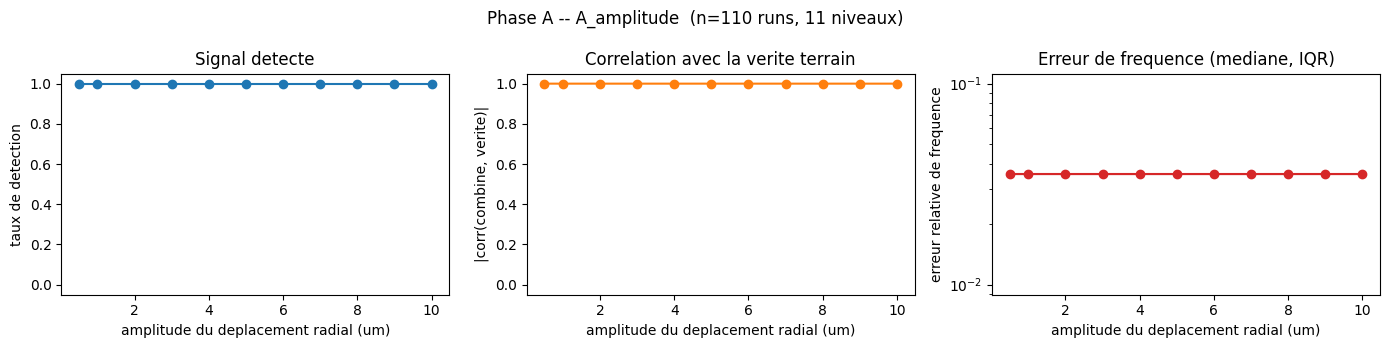

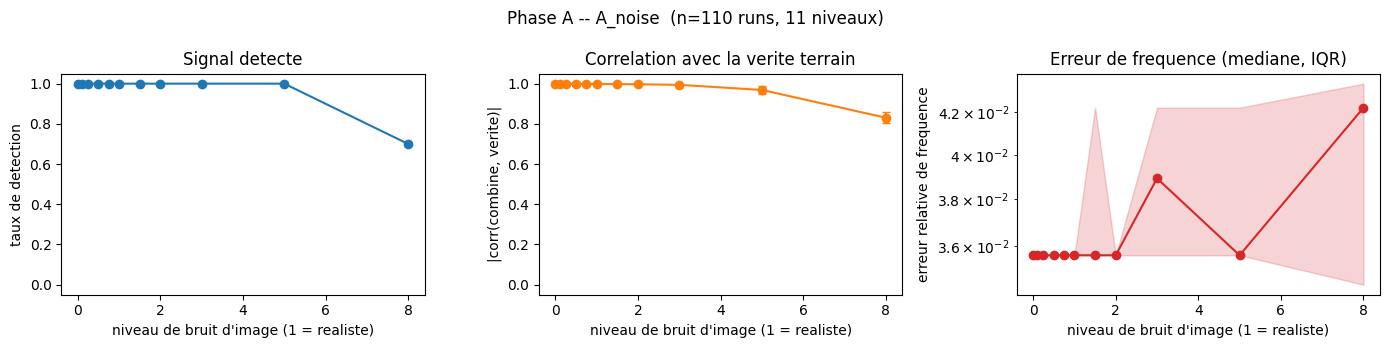

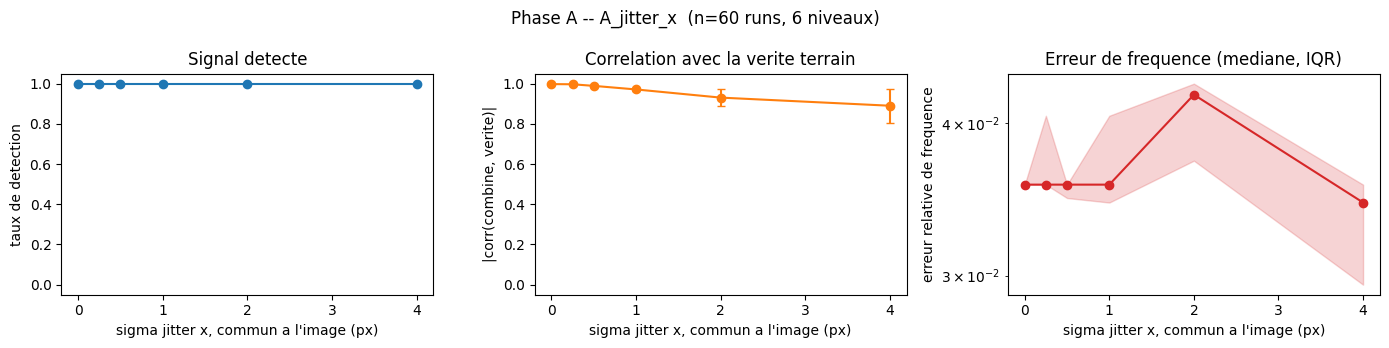

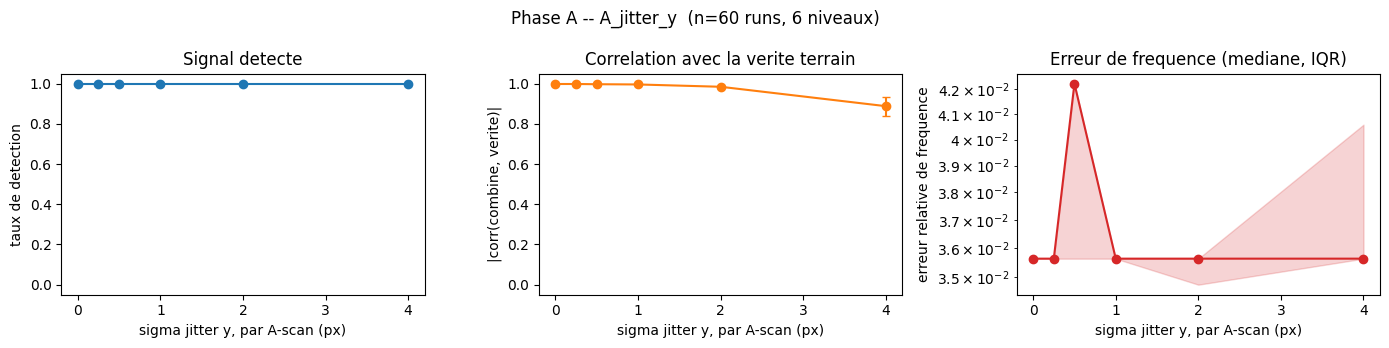

In [4]:
def plot_1d_sweep(df, phase, param, xlabel):
    sub = df[df["phase"] == phase]
    if sub.empty:
        print(f"Aucun run pour la phase {phase!r}.")
        return
    x = np.array(sorted(sub[param].unique()))
    g = sub.groupby(param)
    success_rate = g["detected"].mean().reindex(x)
    corr_mean = g["abs_corr"].mean().reindex(x)
    corr_std = g["abs_corr"].std().reindex(x)
    freq_err_median = g["freq_rel_err"].median().reindex(x)
    freq_err_q1 = g["freq_rel_err"].quantile(0.25).reindex(x)
    freq_err_q3 = g["freq_rel_err"].quantile(0.75).reindex(x)

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    axes[0].plot(x, success_rate, "o-", color="C0")
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].set_ylabel("taux de detection")
    axes[0].set_title("Signal detecte")

    axes[1].errorbar(x, corr_mean, yerr=corr_std, fmt="o-", color="C1", capsize=3)
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_ylabel("|corr(combine, verite)|")
    axes[1].set_title("Correlation avec la verite terrain")

    axes[2].plot(x, freq_err_median, "o-", color="C3")
    axes[2].fill_between(x, freq_err_q1, freq_err_q3, color="C3", alpha=0.2)
    axes[2].set_yscale("log")
    axes[2].set_ylabel("erreur relative de frequence")
    axes[2].set_title("Erreur de frequence (mediane, IQR)")

    for ax in axes:
        ax.set_xlabel(xlabel)
    fig.suptitle(f"Phase A -- {phase}  (n={len(sub)} runs, {sub[param].nunique()} niveaux)")
    fig.tight_layout()
    plt.show()


if not df.empty:
    plot_1d_sweep(df, "A_amplitude", "amplitude_um", "amplitude du deplacement radial (um)")
    plot_1d_sweep(df, "A_noise", "noise_level", "niveau de bruit d'image (1 = realiste)")
    plot_1d_sweep(df, "A_jitter_x", "jitter_x_px", "sigma jitter x, commun a l'image (px)")
    plot_1d_sweep(df, "A_jitter_y", "jitter_y_px", "sigma jitter y, par A-scan (px)")


## Phase B -- grille combinee : toutes les conditions superposees

Memes trois metriques qu'en phase A, mais **toutes les conditions sur les
memes axes** : la couleur porte une variable, le style de trait une seconde,
et la troisieme est en abscisse. Deux lectures complementaires, l'une avec
`jitter_y` en abscisse, l'autre avec `jitter_x`.

La version precedente de cette section faisait une grille `jitter_x x
jitter_y` facettee par niveau de bruit, une figure par amplitude. Elle est
devenue illisible le jour ou le bruit est passe d'un axe de grille a un
**tirage au sort par run** (`sample_noise_level`) : chaque run ayant alors son
propre `noise_level`, `unique()` en renvoyait autant que de runs, et la
fonction produisait une centaine de sous-graphiques d'une seule case chacun.

Le bruit est donc traite ici pour ce qu'il est par construction -- une
variable de nuisance -- et **moyenne a l'interieur de chaque point**. La
derniere figure fait l'inverse et le met en abscisse (en casiers de quantiles),
ce qui est l'usage prevu quand on l'a rendu aleatoire : le lire comme un
regresseur plutot que comme un facteur controle.

Un point agrege les repetitions de sa case ; les cases de moins de `min_runs`
runs sont omises plutot que tracees sur un echantillon trop maigre -- utile
tant qu'un balayage est incomplet.


[avert] 1/675 runs de phase B en echec (0%) : ce sont des EXCEPTIONS, pas des non-detections. Regardez le champ `error` de leurs .npz avant de lire ces courbes comme une limite de detectabilite.


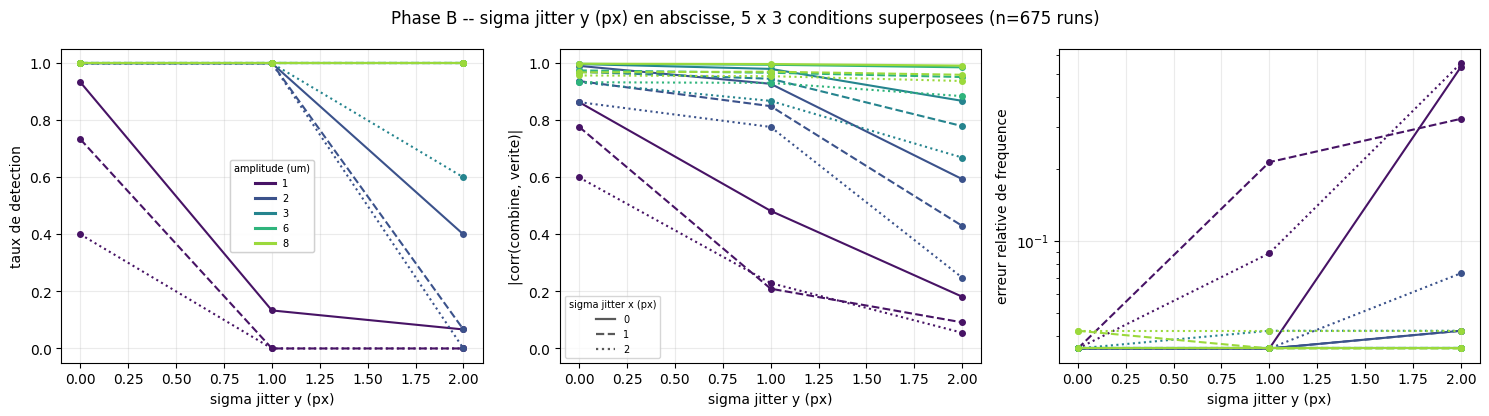

[avert] 1/675 runs de phase B en echec (0%) : ce sont des EXCEPTIONS, pas des non-detections. Regardez le champ `error` de leurs .npz avant de lire ces courbes comme une limite de detectabilite.


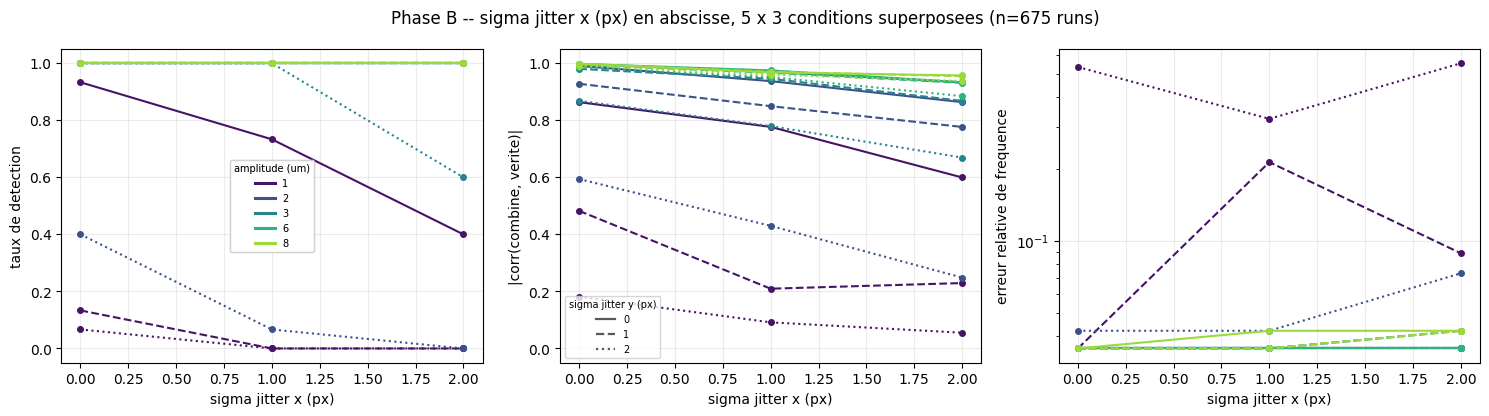

[avert] 1/675 runs de phase B en echec (0%) : ce sont des EXCEPTIONS, pas des non-detections. Regardez le champ `error` de leurs .npz avant de lire ces courbes comme une limite de detectabilite.


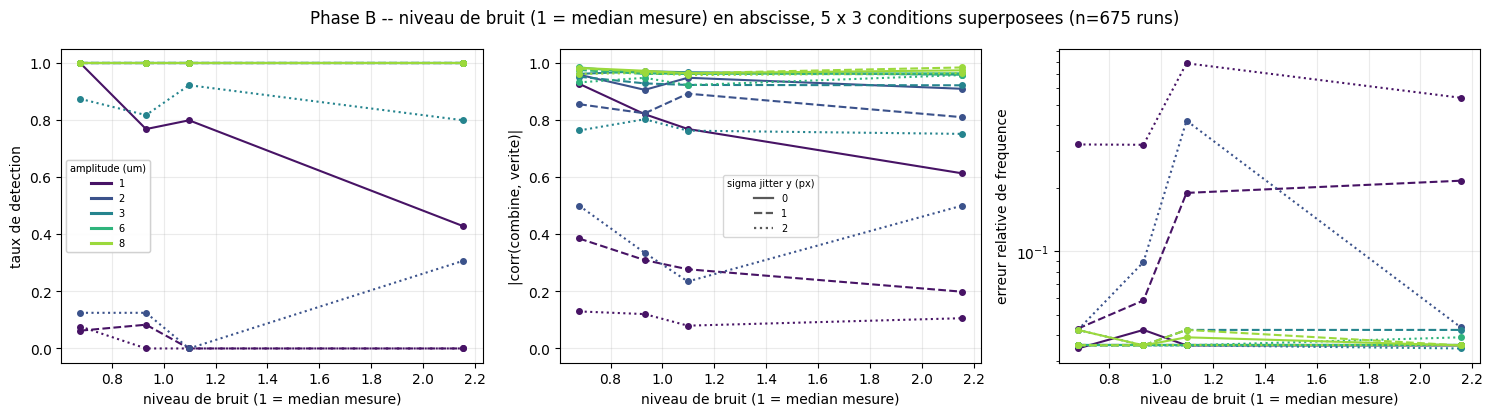

In [5]:
# --- Phase B : toutes les conditions superposees ---------------------------
from matplotlib.lines import Line2D

#: (colonne, agregation sur les repetitions, ylabel, ylim, yscale). Memes
#: metriques que `plot_1d_sweep` en phase A, pour que les deux sections se
#: lisent de la meme facon.
PHASE_B_METRICS = (
    ("detected",     "mean",   "taux de detection",            (-0.05, 1.05), None),
    ("abs_corr",     "mean",   "|corr(combine, verite)|",      (-0.05, 1.05), None),
    ("freq_rel_err", "median", "erreur relative de frequence", None,          "log"),
)

PARAM_LABELS = {
    "amplitude_um": "amplitude (um)",
    "jitter_x_px": "sigma jitter x (px)",
    "jitter_y_px": "sigma jitter y (px)",
    "noise_level": "niveau de bruit (1 = median mesure)",
}

STYLES = ("-", "--", ":", "-.")


def plot_phase_b_overlay(df, x_param, hue, style, min_runs=3, x_bins=None):
    """Les trois metriques de la phase A, toutes conditions superposees.

    `hue` -> couleur, `style` -> style de trait, `x_param` -> abscisse. Un
    point agrege les repetitions de sa case, donc plusieurs niveaux de bruit
    tires au sort : c'est la moyenne sur la nuisance, voulue.

    `x_bins` : nombre de casiers de quantiles a appliquer a `x_param` avant de
    grouper. Indispensable pour mettre `noise_level` en abscisse, qui est
    continu (tire au sort) et n'a donc aucune valeur repetee.
    """
    sub = df[df["phase"] == "B_combined"]
    if sub.empty:
        print("Aucun run de phase B.")
        return

    # Un run `failed` est une EXCEPTION (disque plein, .npz verrouille...), pas
    # une non-detection -- mais il compte comme non-detecte dans `detected` et
    # comme NaN dans les deux autres metriques. Sans ce garde-fou, un balayage
    # casse se lit exactement comme une limite de detectabilite franchie.
    n_failed = int((sub["confidence"] == "failed").sum())
    if n_failed:
        print(f"[avert] {n_failed}/{len(sub)} runs de phase B en echec "
              f"({n_failed / len(sub):.0%}) : ce sont des EXCEPTIONS, pas des "
              "non-detections. Regardez le champ `error` de leurs .npz avant de "
              "lire ces courbes comme une limite de detectabilite.")

    if x_bins is not None:
        sub = sub.copy()
        casiers = pd.qcut(sub[x_param], x_bins, duplicates="drop")
        sub[x_param] = casiers.map(lambda iv: iv.mid).astype(float)

    hues = sorted(sub[hue].unique())
    styles = sorted(sub[style].unique())
    colors = plt.cm.viridis(np.linspace(0.05, 0.85, len(hues)))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    n_courbes = 0
    for ax, (metric, how, ylabel, ylim, yscale) in zip(axes, PHASE_B_METRICS):
        for ci, h in enumerate(hues):
            for si, s in enumerate(styles):
                cellule = sub[(sub[hue] == h) & (sub[style] == s)]
                if cellule.empty:
                    continue
                g = cellule.groupby(x_param)[metric]
                y = g.mean() if how == "mean" else g.median()
                y = y[g.size() >= min_runs]   # case trop maigre -> pas de point
                y = y.dropna()                # metrique indefinie (runs en echec)
                if y.empty:
                    continue
                n_courbes += 1
                ax.plot(y.index, y.values, marker="o", ms=4, lw=1.5,
                        color=colors[ci], ls=STYLES[si % len(STYLES)])
        ax.set_xlabel(PARAM_LABELS.get(x_param, x_param))
        ax.set_ylabel(ylabel)
        if ylim is not None:
            ax.set_ylim(*ylim)
        if yscale is not None:
            ax.set_yscale(yscale)
        ax.grid(alpha=0.25)

    if n_courbes == 0:
        plt.close(fig)
        print(f"Aucune case avec au moins {min_runs} runs -- rien a tracer.")
        return

    # Deux legendes separees : sans cela, 15 entrees "amplitude=1, jitter_x=0"
    # noieraient le graphique. La couleur porte `hue`, le trait porte `style`.
    legende_hue = axes[0].legend(
        handles=[Line2D([], [], color=colors[i], lw=2.2, label=f"{h:g}")
                 for i, h in enumerate(hues)],
        title=PARAM_LABELS.get(hue, hue), fontsize=7, title_fontsize=7, loc="best",
    )
    axes[0].add_artist(legende_hue)
    axes[1].legend(
        handles=[Line2D([], [], color="0.35", lw=1.6, ls=STYLES[i % len(STYLES)],
                        label=f"{s:g}") for i, s in enumerate(styles)],
        title=PARAM_LABELS.get(style, style), fontsize=7, title_fontsize=7, loc="best",
    )

    fig.suptitle(
        f"Phase B -- {PARAM_LABELS.get(x_param, x_param)} en abscisse, "
        f"{len(hues)} x {len(styles)} conditions superposees (n={len(sub)} runs)"
    )
    fig.tight_layout()
    plt.show()


if not df.empty:
    # Jitter y en abscisse : la degradation la plus severe (chaque A-scan bouge
    # pour son compte), amplitude en couleur, jitter x en style de trait.
    plot_phase_b_overlay(df, x_param="jitter_y_px", hue="amplitude_um",
                         style="jitter_x_px")
    # La meme lecture avec les deux jitters echanges.
    plot_phase_b_overlay(df, x_param="jitter_x_px", hue="amplitude_um",
                         style="jitter_y_px")
    # Le bruit en abscisse : il est tire au sort a chaque run, donc en casiers
    # de quantiles. C'est ce que le tirage aleatoire permet et que la grille
    # facettee empechait de lire.
    plot_phase_b_overlay(df, x_param="noise_level", hue="amplitude_um",
                         style="jitter_y_px", x_bins=4)


## Regarder un run individuel

Selection automatique par defaut (le run avec la plus faible erreur de
frequence) -- remplacez `RUN_TAG` par un `tag` de `summary.csv` pour explorer
un point precis du balayage (ex. juste avant/apres une limite identifiee
ci-dessus).


In [ ]:
if not df.empty:
    idx_data = 0
    RUN_TAG = "combined_A02.0_Jx1.00_Jy1.00_N0.77_rep9"
    npz_path = Path(df.loc[df["tag"] == RUN_TAG, "npz_path"].iloc[0])
else:
    RUN_TAG = None
    npz_path = None  # renseignez un chemin .npz manuellement si summary.csv est absent

assert npz_path is not None and npz_path.exists(), (
    "Aucun run disponible -- lancez d'abord simulate_svd_radial_gaussians.py, "
    "ou renseignez npz_path manuellement."
)

d = np.load(npz_path, allow_pickle=True)
if "error" in d:
    print(f"Ce run a echoue : {d['error']}")
else:
    print(f"{RUN_TAG}")
    print(
        f"  amplitude={float(d['amplitude_um']):.1f}um  "
        f"jitter_x={float(d['jitter_x_px']):.2f}px  jitter_y={float(d['jitter_y_px']):.2f}px  "
        f"bruit={float(d['noise_level']):.2f}"
    )
    print(
        f"  frequence estimee = {float(d['rate_freq']) * 60:.1f} bpm  "
        f"(confiance = {d['rate_confidence']})"
    )
    print(f"  erreur relative de frequence = {float(d['freq_rel_err']):.1%}")
    print(f"  correlation combine/verite = {float(d['corr_combined_vs_truth']):.3f}")
    print(
        f"  {int(d['selected_indices'].size)} composante(s) SVD retenue(s), "
        f"objectif = {float(d['objective']):.4g}"
    )


combined_A02.0_Jx0.00_Jy0.00_N0.88_rep2
  amplitude=2.0um  jitter_x=0.00px  jitter_y=0.00px  bruit=0.88
  frequence estimee = 66.5 bpm  (confiance = high)
  erreur relative de frequence = 3.6%
  correlation combine/verite = -0.993
  4 composante(s) SVD retenue(s), objectif = -0.143


### U, S, V -- vecteurs singuliers et valeurs singulieres

Convention du package (matrice temps x pixels) : `U` = vecteurs singuliers
GAUCHE (formes d'onde temporelles, colonnes unitaires), `S` = valeurs
singulieres, `V` = vecteurs singuliers DROITS (cartes spatiales sur l'anneau,
deja unitaires). Rouge = composante retenue par `OptimizedSpectralCombination`.


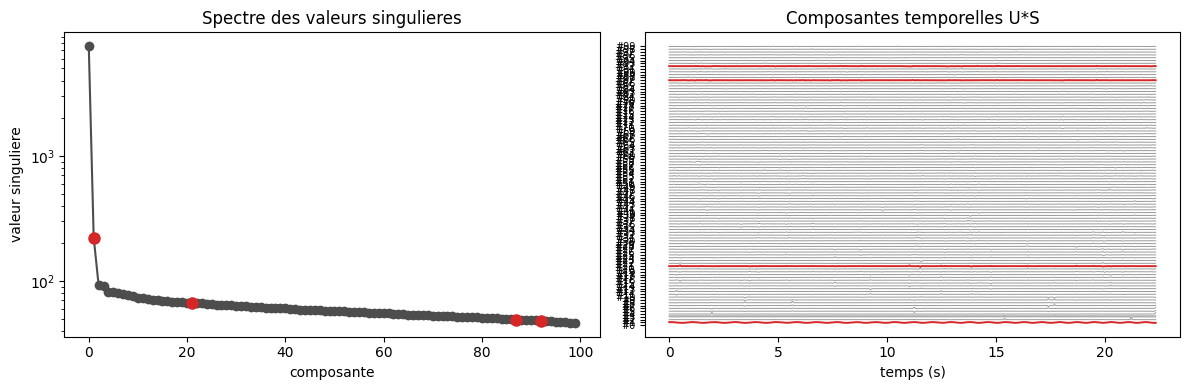

In [30]:
if "error" not in d:
    U, S, V = d["U"], d["S"], d["V"]
    uniform_time = d["uniform_time"]
    kept_mask = d["kept_mask"]
    t_kept = uniform_time[kept_mask]  # U/V sont sur la grille "kept", pas la grille complete
    selected = set(d["selected_indices"].tolist())
    K = U.shape[1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].semilogy(np.arange(K), S, "o-", color="0.3")
    for k in selected:
        axes[0].plot(k, S[k], "o", color="C3", ms=8)
    axes[0].set_xlabel("composante")
    axes[0].set_ylabel("valeur singuliere")
    axes[0].set_title("Spectre des valeurs singulieres")

    US = U * S[None, :]
    offsets = np.arange(K) * (3 * np.nanstd(US))
    for k in range(K):
        color = "C3" if k in selected else "0.6"
        lw = 1.4 if k in selected else 0.7
        axes[1].plot(t_kept, US[:, k] + offsets[k], color=color, lw=lw)
    axes[1].set_yticks(offsets)
    axes[1].set_yticklabels([f"#{k}" for k in range(K)], fontsize=7)
    axes[1].set_xlabel("temps (s)")
    axes[1].set_title("Composantes temporelles U*S")
    fig.tight_layout()
    plt.show()


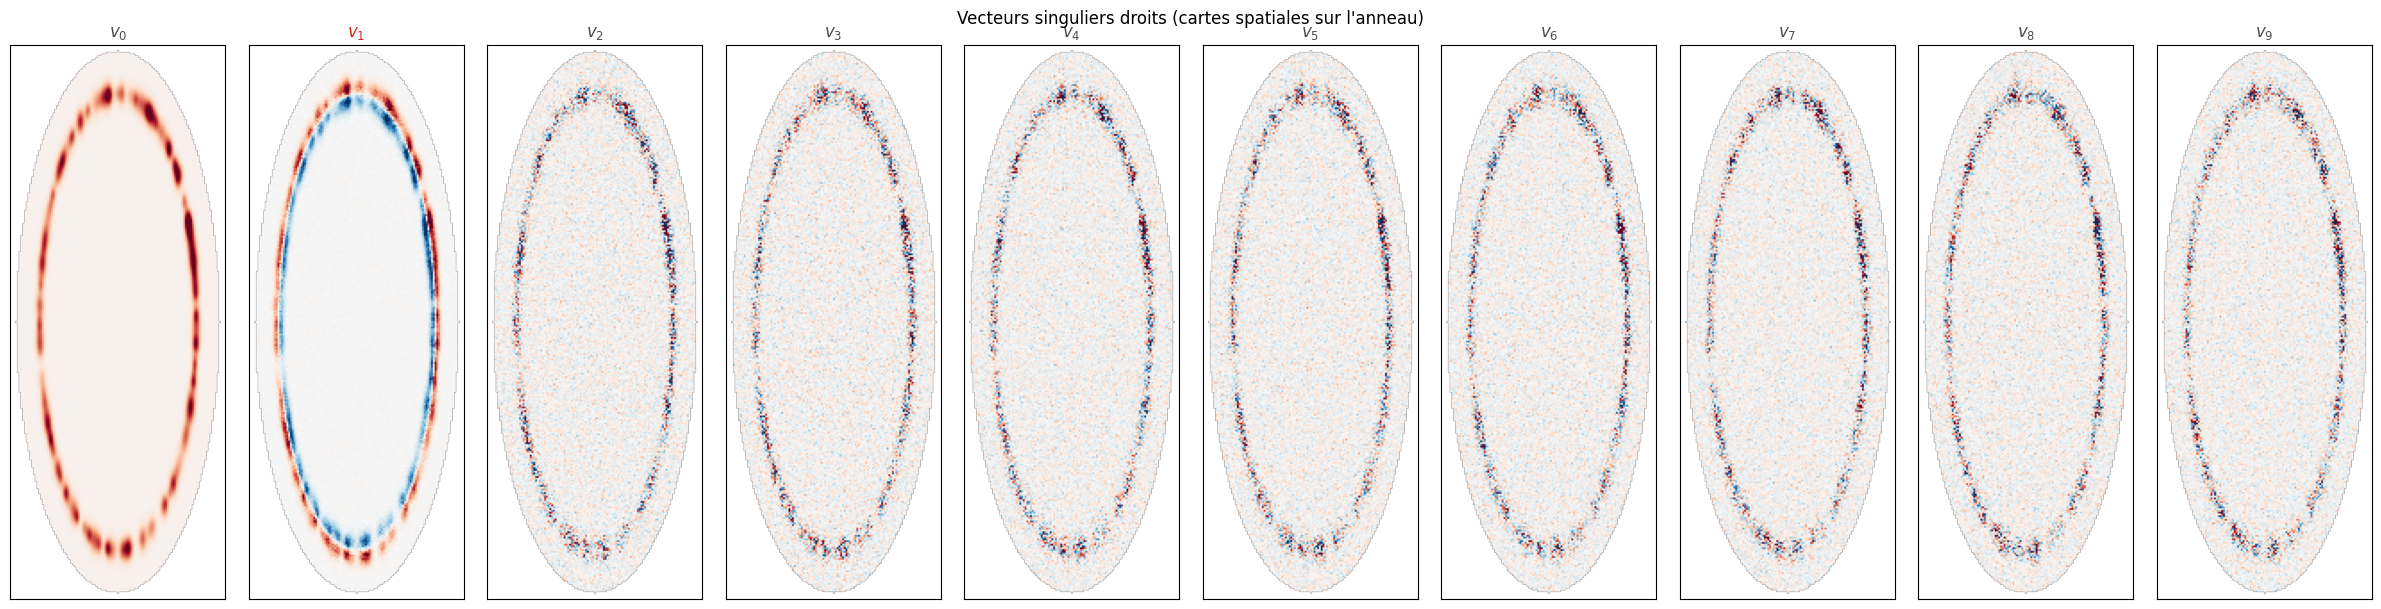

In [31]:
if "error" not in d:
    calib_partial = sim.RealCalibration(
        scale_x_um=float(d["scale_x_um"]), scale_y_um=float(d["scale_y_um"]),
        fs_hz=float(d["fs_hz"]), n_frames=len(uniform_time),
        duration_s=(len(uniform_time) - 1) / float(d["fs_hz"]),
    )
    shape = sim.crop_shape(calib_partial)
    mask2d = sim.build_fixed_mask(shape)

    n_show = min(10, K)
    fig, axes = plt.subplots(
        1, n_show, figsize=(2.4 * n_show, 2.4 * shape[0] / shape[1])
    )
    axes = np.atleast_1d(axes)
    vmax = np.nanpercentile(np.abs(V[:, :n_show]), 99.5)
    for k in range(n_show):
        spatial = np.full(mask2d.shape, np.nan)
        spatial[mask2d] = V[:, k]
        color = "C3" if k in selected else "0.3"
        axes[k].imshow(spatial, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axes[k].set_title(f"$v_{{{k}}}$", color=color)
        axes[k].set_xticks([])
        axes[k].set_yticks([])
    fig.suptitle("Vecteurs singuliers droits (cartes spatiales sur l'anneau)")
    fig.tight_layout()
    plt.show()


### Signal agrege vs verite terrain

`combined_uniform` (sortie de `OptimizedSpectralCombination`) mis a l'echelle
et signe aligne sur le deplacement radial impose, superpose a la verite
terrain -- puis periodogramme de Lomb-Scargle du signal agrege, avec la
frequence retenue par le pipeline et la frequence moyenne vraie du chirp.


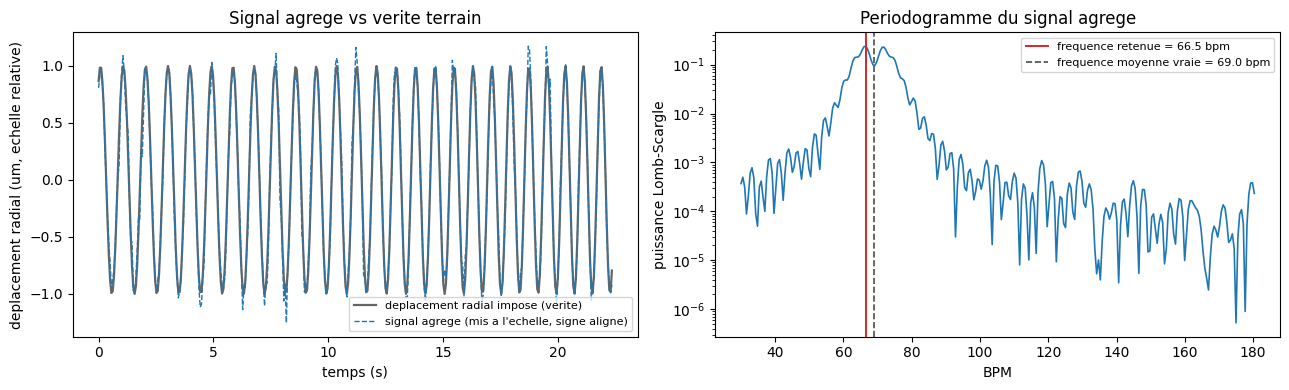

In [32]:
if "error" not in d:
    combined = d["combined_uniform"]
    r_true = d["r_true_uniform"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sign = np.sign(np.corrcoef(combined[kept_mask], r_true[kept_mask])[0, 1]) or 1.0
    combined_scaled = (
        sign * combined / np.nanstd(combined[kept_mask]) * np.nanstd(r_true[kept_mask])
    )
    axes[0].plot(uniform_time, r_true, color="0.4", lw=1.6, label="deplacement radial impose (verite)")
    axes[0].plot(
        uniform_time, combined_scaled, color="C0", lw=1.0, ls="--",
        label="signal agrege (mis a l'echelle, signe aligne)",
    )
    axes[0].set_xlabel("temps (s)")
    axes[0].set_ylabel("deplacement radial (um, echelle relative)")
    axes[0].legend(fontsize=8)
    axes[0].set_title("Signal agrege vs verite terrain")

    combined_kept = combined[kept_mask] - np.nanmean(combined[kept_mask])
    freqs = d["rate_freqs"]
    power = lomb_scargle_power(t_kept, combined_kept, freqs)
    axes[1].semilogy(freqs * 60.0, power, color="C0", lw=1.2)
    axes[1].axvline(
        float(d["rate_freq"]) * 60.0, color="C3", lw=1.4,
        label=f"frequence retenue = {float(d['rate_freq']) * 60:.1f} bpm",
    )
    f_true_mean_bpm = float(np.mean(d["f_true_uniform"])) * 60.0
    axes[1].axvline(
        f_true_mean_bpm, color="0.3", ls="--", lw=1.2,
        label=f"frequence moyenne vraie = {f_true_mean_bpm:.1f} bpm",
    )
    axes[1].set_xlabel("BPM")
    axes[1].set_ylabel("puissance Lomb-Scargle")
    axes[1].legend(fontsize=8)
    axes[1].set_title("Periodogramme du signal agrege")
    fig.tight_layout()
    plt.show()


### Phase de Hilbert vs frequence instantanee vraie

Phase mesuree (transformee de Hilbert du signal agrege) et frequence
cardiaque instantanee derivee, comparees a la phase et frequence
instantanee VRAIES du chirp impose. Segments hors phase fiable
(`good_uniform` faux) ombres.


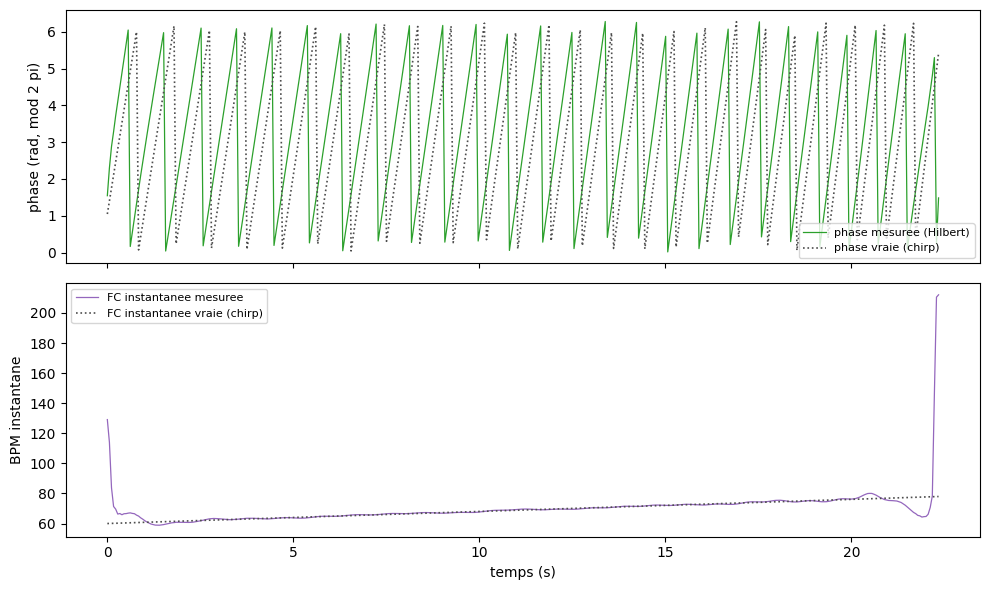

In [33]:
if "error" not in d:
    phase_uniform = d["phase_uniform"]
    inst_bpm = d["inst_bpm"]
    good_u = d["good_uniform"]
    true_phase = sim.chirp_phase(uniform_time, float(uniform_time[-1])) % (2 * np.pi)
    f_true_bpm = d["f_true_uniform"] * 60.0

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(uniform_time, phase_uniform, color="C2", lw=0.9, label="phase mesuree (Hilbert)")
    axes[0].plot(uniform_time, true_phase, color="0.3", lw=1.2, ls=":", label="phase vraie (chirp)")
    axes[0].fill_between(
        uniform_time, 0, 2 * np.pi, where=~good_u, color="0.85", alpha=0.5, step="mid"
    )
    axes[0].set_ylabel("phase (rad, mod 2 pi)")
    axes[0].legend(fontsize=8)

    axes[1].plot(uniform_time, inst_bpm, color="C4", lw=0.9, label="FC instantanee mesuree")
    axes[1].plot(
        uniform_time, f_true_bpm, color="0.3", lw=1.2, ls=":", label="FC instantanee vraie (chirp)"
    )
    axes[1].fill_between(
        uniform_time, np.nanmin(f_true_bpm), np.nanmax(f_true_bpm), where=~good_u,
        color="0.85", alpha=0.5, step="mid",
    )
    axes[1].set_xlabel("temps (s)")
    axes[1].set_ylabel("BPM instantane")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    plt.show()


### Regenerer et visualiser le cube synthetique

Aucun cube n'est sauvegarde par le script (regenerable a partir des
parametres + graine sauvegardes). Reproduit exactement la meme sequence
alea que `run_one` (jitter puis bruit, sur le meme generateur), donc le
cube obtenu ici est identique a celui effectivement mesure pour ce run.


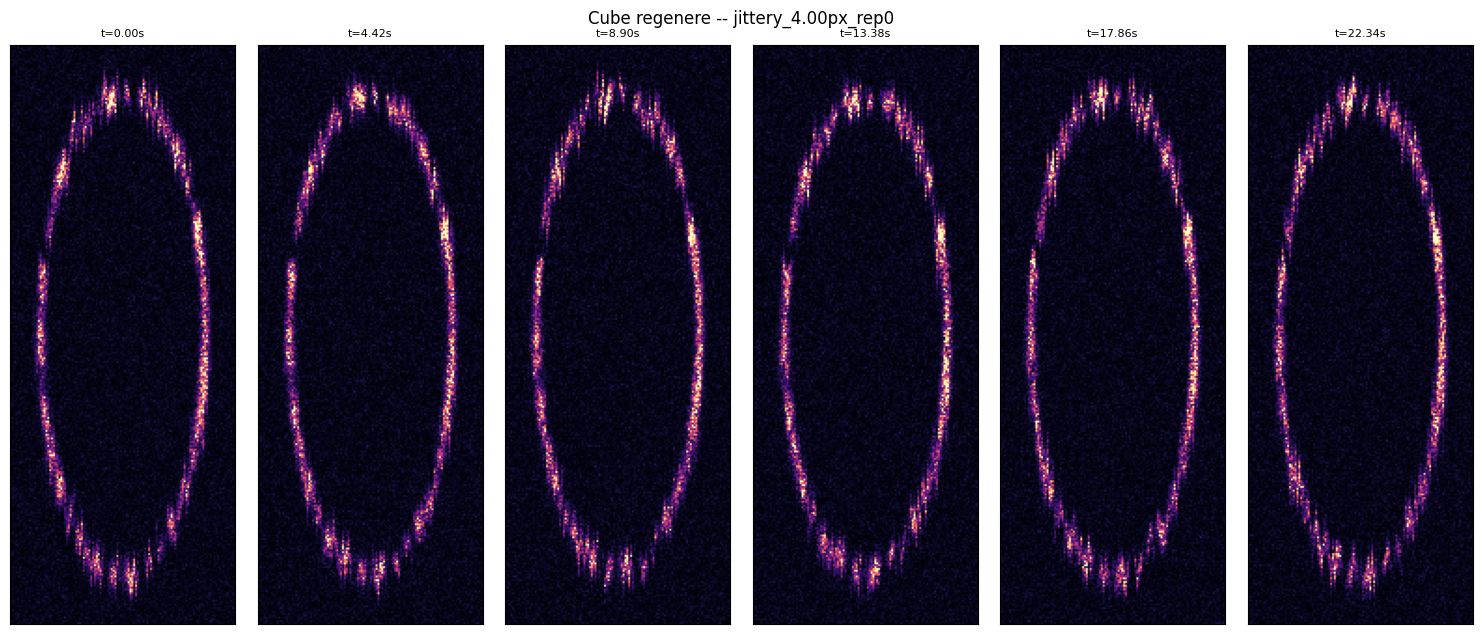

In [ ]:
def regenerate_cube(d):
    n_frames = len(d["uniform_time"])
    calib = sim.RealCalibration(
        scale_x_um=float(d["scale_x_um"]), scale_y_um=float(d["scale_y_um"]),
        fs_hz=float(d["fs_hz"]), n_frames=n_frames,
        duration_s=(n_frames - 1) / float(d["fs_hz"]),
    )
    anatomy = sim.build_ring_anatomy()
    t = np.arange(n_frames) / calib.fs_hz
    duration_s = float(t[-1])
    shape = sim.crop_shape(calib)
    rng = np.random.default_rng(int(d["seed"]))
    jitter_x, jitter_y = sim.sample_jitter(
        n_frames, shape[1],
        sim.JitterParams(float(d["jitter_x_px"]), float(d["jitter_y_px"])), rng,
    )
    cube = sim.render_cube(
        anatomy, calib, t, duration_s, float(d["amplitude_um"]), jitter_x, jitter_y, shape
    )
    cube = sim.add_image_noise(cube, float(d["noise_level"]), rng)
    return cube, calib, shape


if "error" not in d:
    cube, calib_regen, shape = regenerate_cube(d)
    n_frames = cube.shape[0]
    show_idx = np.linspace(0, n_frames - 1, 6).astype(int)
    fig, axes = plt.subplots(1, 6, figsize=(15, 15 * shape[0] / shape[1] / 6))
    vlo, vhi = np.percentile(cube, [0.5, 99.5])
    for ax, i in zip(axes, show_idx):
        ax.imshow(cube[i], cmap="magma", vmin=vlo, vmax=vhi)
        ax.set_title(f"t={i / calib_regen.fs_hz:.2f}s", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(f"Cube regenere -- {RUN_TAG}")
    fig.tight_layout()
    plt.show()


## Statistiques de bruit mesurees sur les vraies images

Le `noise_level` du balayage ci-dessus est un multiplicateur pose a la main
(`1` = "reglages realistes"). Cette section le confronte a la mesure :
`Astronauts/quantify_image_noise.py` parcourt **tous** les cubes recales de
`SegmentationVariations`, compare chaque frame a la moyenne temporelle de son
cube, et ajuste les modeles de bruit candidats sur les statistiques par pixel.

Pour un pixel dont la reflectivite `R` est constante dans le temps, le modele
de la simulation (`sim.add_image_noise` : `I = R * Gamma(L, 1/L) + N(0, floor)`)
donne `E[I] = R` et **`Var[I] = R^2 / L + floor^2`**. On lit donc `L` et `floor`
dans la pente et l'ordonnee a l'origine de `var` en fonction de `mu^2`, puis on
les retraduit en `noise_level` via les relations posees par le script de
simulation (`L = N_LOOKS_REALISTIC / noise_level^2`,
`floor = BRUIT_ADDITIF_REALISTIC * noise_level`).

Deux modeles concurrents sont ajustes en meme temps, parce que le premier
resultat de la mesure est que la variance croit comme `mu`, pas comme `mu^2` :
Poisson (`var = k * mu + floor^2`) et une loi puissance libre (`var = c * mu^p`,
dont l'exposant `p` tranche : 1 = Poisson, 2 = speckle multiplicatif,
0 = additif pur). Les B-scans exportes etant compresses logarithmiquement, le
speckle n'y est plus multiplicatif -- d'ou l'ecart.

Chaque cube est analyse **avec et sans normalisation** d'intensite par frame
(celle de `PixelTraceConfig.normalize_intensity`, appliquee en amont de la SVD).
L'ecart entre les deux mesure la part de la variance qui n'est qu'une
fluctuation de **gain global** par frame (`frame_gain_cv`) : multiplicative,
commune a toute l'image, et absente de la simulation aujourd'hui.

`FIT_KIND` bascule entre la variance demandee (`"mean"`, ecart a la moyenne du
cube) et un controle (`"lag1"`, variance estimee sur frames consecutives, qui
attenue la pulsation et le residu de recalage -- ils gonflent la premiere).


In [ ]:
# --- Statistiques de bruit mesurees sur les vraies images ------------------
NOISE_CSV = (
    ASTRONAUTS_DIR / "simulation_output" / "image_noise" / "image_noise_summary.csv"
)
FIT_KIND = "mean"   # "mean" = ecart a la moyenne du cube ; "lag1" = controle
R2_MIN = 0.5        # cube dont aucun modele n'explique la variance -> ecarte

assert NOISE_CSV.exists(), (
    f"{NOISE_CSV} absent -- lancez d'abord "
    "`python Astronauts/quantify_image_noise.py`."
)

VARIANTES = ["brut", "normalise"]
COULEUR = {"brut": "C0", "normalise": "C1"}

dfn = pd.read_csv(NOISE_CSV)
n_cubes = dfn["npz_path"].nunique()
bon = dfn[f"{FIT_KIND}_power_r2"] >= R2_MIN
n_ecartes = int((~bon & (dfn["variant"] == "brut")).sum())
dfn = dfn[bon]
n_repli = int(
    ((dfn["variant"] == "brut") & (dfn["roi_frame_fraction"] < 1.0)).sum()
)
print(
    f"{n_cubes} cubes analyses, {n_ecartes} ecartes (R2 de la loi puissance < {R2_MIN} :"
    " variance sans lien avec l'intensite, typiquement un recalage parti)"
)
print(
    f"  dont {n_repli} avec une ROI de repli (intersection stricte du masque vide,"
    " cf. ROI_FALLBACK_FRAME_FRACTION dans le script)"
)


def charger(variant):
    """Courbes var(mu) par casier + histogramme des residus, par cube."""
    out = {}
    for path in dfn.loc[dfn["variant"] == variant, "npz_path"]:
        z = np.load(path)
        p = f"{variant}_{FIT_KIND}_"
        out[path] = {
            "mu": z[p + "bin_mu"].astype(float),
            "mu2": z[p + "bin_mu2"].astype(float),
            "var": z[p + "bin_var"].astype(float),
            "count": z[p + "bin_count"].astype(float),
            "hist": z[f"{variant}_resid_hist"].astype(float),
            "hist_edges": z[f"{variant}_resid_hist_edges"].astype(float),
        }
    return out


courbes = {v: charger(v) for v in VARIANTES}


def fit3(c):
    """Ajustement CONJOINT des trois termes : var = c0 + c1*mu + c2*mu^2.

    Les trois modeles du script sont ajustes separement (chacun impose sa
    forme) ; ici on les met en concurrence dans un seul ajustement, pour
    pouvoir dire quelle PART de la variance chacun porte -- ce qui est
    l'information dont la simulation a besoin.
    """
    A = np.stack([np.ones_like(c["mu"]), c["mu"], c["mu2"]], axis=1)
    sw = np.sqrt(c["count"])
    coef, *_ = np.linalg.lstsq(A * sw[:, None], c["var"] * sw, rcond=None)
    return coef


def contributions(variant):
    """Part de variance portee par chaque terme, evaluee a l'intensite
    mediane de la ROI du cube (les trois termes n'y sont pas commensurables
    dans l'absolu)."""
    rows = []
    for path, c in courbes[variant].items():
        c0, c1, c2 = fit3(c)
        mu_ref = float(np.average(c["mu"], weights=c["count"]))
        parts = np.array([c0, c1 * mu_ref, c2 * mu_ref**2])
        total = parts.sum()
        rows.append(
            {
                "npz_path": path,
                "mu_ref": mu_ref,
                "c0": c0, "c1": c1, "c2": c2,
                "var_ref": total,
                "frac_const": parts[0] / total,
                "frac_poisson": parts[1] / total,
                "frac_speckle": parts[2] / total,
            }
        )
    return pd.DataFrame(rows)


contrib = {v: contributions(v) for v in VARIANTES}
dfb = dfn[dfn["variant"] == "brut"]

# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))

# (1) var vs mu : la forme du bruit, avant tout modele
ax = axes[0, 0]
for variant in VARIANTES:
    for c in courbes[variant].values():
        ax.plot(c["mu"], c["var"], color=COULEUR[variant], lw=0.4, alpha=0.25)
grille = np.geomspace(
    np.median([c["mu"][0] for c in courbes["brut"].values()]),
    np.median([c["mu"][-1] for c in courbes["brut"].values()]),
    40,
)
medianes = {}
for variant in VARIANTES:
    ys = [
        np.interp(np.log(grille), np.log(c["mu"]), np.log(c["var"]),
                  left=np.nan, right=np.nan)
        for c in courbes[variant].values()
    ]
    medianes[variant] = np.exp(np.nanmedian(np.vstack(ys), axis=0))
    ax.plot(grille, medianes[variant], color=COULEUR[variant], lw=2.4,
            label=f"mediane -- {variant}")
milieu = len(grille) // 2
ancre = medianes["brut"][milieu]
for pente, style, nom in ((1.0, "--", "Poisson"), (2.0, ":", "speckle")):
    ax.plot(grille, ancre * (grille / grille[milieu]) ** pente,
            color="0.35", ls=style, lw=1.1, label=f"pente {pente:g} ({nom})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("intensite moyenne du pixel, mu (niveaux)")
ax.set_ylabel("variance temporelle (niveaux^2)")
ax.set_title("Variance vs moyenne, un trait par cube")
ax.legend(fontsize=7)

# (2) exposant de la loi puissance
ax = axes[0, 1]
bins = np.linspace(-0.5, 2.2, 34)
for variant in VARIANTES:
    ax.hist(dfn.loc[dfn["variant"] == variant, f"{FIT_KIND}_power_p"], bins=bins,
            color=COULEUR[variant], alpha=0.55, label=variant)
for x, nom in ((0.0, "additif"), (1.0, "Poisson"), (2.0, "speckle")):
    ax.axvline(x, color="0.35", ls="--", lw=1.0)
    ax.text(x, ax.get_ylim()[1] * 0.96, nom, rotation=90, fontsize=7,
            ha="right", va="top", color="0.35")
ax.set_xlabel("exposant p de var = c * mu^p")
ax.set_ylabel("nombre de cubes")
ax.set_title("Quel modele de bruit ?")
ax.legend(fontsize=8)

# (3) part de variance portee par chaque terme (ajustement conjoint)
ax = axes[0, 2]
etiquettes = ["constante", "~ mu\n(Poisson)", "~ mu^2\n(speckle)"]
donnees = [contrib["brut"][k].clip(-0.2, 1.2)
           for k in ("frac_const", "frac_poisson", "frac_speckle")]
bp = ax.boxplot(donnees, showfliers=False, patch_artist=True)
for patch, couleur in zip(bp["boxes"], ("0.6", "C2", "C3")):
    patch.set_facecolor(couleur); patch.set_alpha(0.6)
ax.axhline(0.0, color="0.4", lw=0.8)
ax.set_xticks(range(1, 4)); ax.set_xticklabels(etiquettes, fontsize=8)
ax.set_ylabel("part de la variance a mu typique (variante brut)")
ax.set_title("Ou est la variance ? (ajustement conjoint des 3 termes)")

# (4) noise_level equivalent de la simulation
ax = axes[1, 0]
for col, couleur, nom in (
    (f"{FIT_KIND}_noise_level_speckle", "C3", "depuis le terme speckle"),
    (f"{FIT_KIND}_noise_level_floor_mean", "0.4", "depuis le plancher additif (ancre moyenne)"),
    (f"{FIT_KIND}_noise_level_floor_p90", "C4", "depuis le plancher additif (ancre p90)"),
):
    v = dfb[col].replace([np.inf, -np.inf], np.nan).dropna()
    ax.hist(v, bins=np.geomspace(0.01, 20, 40), color=couleur, alpha=0.5, label=nom)
ax.axvline(sim.REALISTIC_NOISE_LEVEL, color="k", lw=1.6,
           label=f"noise_level = {sim.REALISTIC_NOISE_LEVEL:g} (pose par la simulation)")
ax.set_xscale("log")
ax.set_xlabel("noise_level equivalent")
ax.set_ylabel("nombre de cubes")
ax.set_title("Le noise_level de la simulation, vu par la mesure")
ax.legend(fontsize=7)

# (5) ce que la normalisation par frame enleve
ax = axes[1, 1]
fusion = contrib["brut"].merge(contrib["normalise"], on="npz_path",
                               suffixes=("_brut", "_norm"))
gain_cv = (dfn[dfn["variant"] == "brut"]
           .set_index("npz_path")["frame_gain_cv"]
           .reindex(fusion["npz_path"]).to_numpy())
ax.scatter(gain_cv, fusion["var_ref_norm"] / fusion["var_ref_brut"],
           s=18, color="C1", alpha=0.7)
ax.axhline(1.0, color="0.4", lw=1.0)
ax.set_xlabel("fluctuation de gain par frame (ecart-type relatif)")
ax.set_ylabel("variance normalisee / variance brute")
ax.set_title("Part de la variance qui n'est qu'un gain global")

# (6) forme de la distribution du bruit
ax = axes[1, 2]
for variant in VARIANTES:
    hists = np.vstack([c["hist"] / c["hist"].sum() for c in courbes[variant].values()])
    edges = next(iter(courbes[variant].values()))["hist_edges"]
    centres = 0.5 * (edges[:-1] + edges[1:])
    largeur = edges[1] - edges[0]
    ax.plot(centres, np.median(hists, axis=0) / largeur, color=COULEUR[variant],
            lw=1.6, label=f"mesure -- {variant}")
x = np.linspace(-6, 6, 400)
ax.plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), color="0.35", ls="--", lw=1.2,
        label="N(0, 1)")
ax.set_yscale("log"); ax.set_ylim(1e-5, 1.0)
ax.set_xlabel("residu standardise (I - mu) / sigma")
ax.set_ylabel("densite")
ax.set_title(f"Forme du bruit (asymetrie mediane = "
             f"{dfb['resid_skew'].median():+.2f})")
ax.legend(fontsize=8)

fig.suptitle(
    f"Bruit d'image mesure sur {dfn['npz_path'].nunique()} cubes recales "
    f"(variance = {FIT_KIND})", fontsize=12,
)
fig.tight_layout()
plt.show()


# --- Recapitulatif chiffre, a reporter dans la simulation ------------------
def med_iqr(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()
    return f"{s.median():.3g} [{s.quantile(.25):.3g}, {s.quantile(.75):.3g}]"


print(f"\n=== Mesure (mediane [IQR] sur les cubes retenus, variance = {FIT_KIND}) ===")
for variant in VARIANTES:
    s = dfn[dfn["variant"] == variant]
    c = contrib[variant]
    print(f"\n-- {variant} --")
    print(f"  exposant p                       : {med_iqr(s[f'{FIT_KIND}_power_p'])}")
    print(f"  part constante / Poisson / speckle : "
          f"{c['frac_const'].median():.0%} / {c['frac_poisson'].median():.0%} / "
          f"{c['frac_speckle'].median():.0%}")
    print(f"  contraste de speckle sqrt(a)     : "
          f"{med_iqr(s[f'{FIT_KIND}_speckle_contrast'])}  "
          f"(soit L = {med_iqr(s[f'{FIT_KIND}_speckle_n_looks'])} looks)")
    print(f"  plancher additif / intensite moy.: {med_iqr(s[f'{FIT_KIND}_floor_rel_mean'])}")
    print(f"  fluctuation de gain par frame    : {med_iqr(s['frame_gain_cv'])}")
    print(f"  noise_level equivalent (speckle) : "
          f"{med_iqr(s[f'{FIT_KIND}_noise_level_speckle'])}")
    print(f"  noise_level equivalent (plancher): "
          f"{med_iqr(s[f'{FIT_KIND}_noise_level_floor_p90'])}")

# Reference d'intensite de la simulation, sauvegardee avec chaque cube : sert a
# retraduire un plancher mesure en niveaux de gris vers les unites de la sim.
ref = np.load(dfb["npz_path"].iloc[0])
R_mean_sim, R_p90_sim = float(ref["sim_R_mean"]), float(ref["sim_R_p90"])

# Les trois termes PAR PIXEL se lisent sur la variante NORMALISEE : la variance
# brute contient deja la fluctuation de gain, que la simulation reinjecte
# ensuite explicitement (GAIN_SIGMA_REALISTIC). Les lire sur la brute
# compterait le gain deux fois.
dfnorm = dfn[dfn["variant"] == "normalise"]
L_mesure = dfnorm[f"{FIT_KIND}_speckle_n_looks"].median()
floor_rel = dfnorm[f"{FIT_KIND}_floor_rel_mean"].median()
floor_sim = floor_rel * R_mean_sim
# Terme en mu ancre sur la MEME reference que le plancher (l'intensite moyenne),
# sinon les deux constantes ne sont pas commensurables. La colonne toute faite
# `poisson_k_sim` du CSV utilise l'ancrage p90, ~23% plus haut : l'ecart entre
# les deux est l'incertitude de la conversion vers l'echelle simulee.
k_sim = (
    dfnorm[f"{FIT_KIND}_poisson_k"].median()
    * R_mean_sim
    / dfnorm["mu_mean"].median()
)
gain_cv = dfb["frame_gain_cv"].median()
parts = contrib["brut"][["frac_const", "frac_poisson", "frac_speckle"]].median()

# Dispersion du bruit d'une FRAME a l'autre. Les residus standardises ont des
# queues bien plus lourdes qu'une gaussienne (panneau 6) ; lues comme un melange
# d'echelles -- une echelle de bruit s propre a chaque frame --, l'exces de
# kurtosis K donne sigma_log = sqrt(ln(1 + K/3) / 4). MAJORANT : les evenements
# de mouvement residuel epaississent eux aussi les queues.
sigma_log_frame = float(
    np.sqrt(
        np.log1p(dfnorm["resid_excess_kurtosis"].clip(lower=0) / 3.0) / 4.0
    ).median()
)

nl_speckle = dfb[f"{FIT_KIND}_noise_level_speckle"].median()
nl_floor = dfb[f"{FIT_KIND}_noise_level_floor_p90"].median()

print(f"""
=== Constantes en vigueur dans simulate_svd_radial_gaussians.py, vs mesure ===
  (les trois premieres lues sur la variante NORMALISEE, le gain etant modelise
   a part -- sinon il compterait deux fois)
  N_LOOKS_REALISTIC       = {sim.N_LOOKS_REALISTIC:<8g} mesure : {L_mesure:.0f}
  BRUIT_ADDITIF_REALISTIC = {sim.BRUIT_ADDITIF_REALISTIC:<8g} mesure : {floor_sim:.3f}
  K_POISSON_REALISTIC     = {sim.K_POISSON_REALISTIC:<8g} mesure : {k_sim:.4f}
  GAIN_SIGMA_REALISTIC    = {sim.GAIN_SIGMA_REALISTIC:<8g} mesure : {gain_cv:.3f}
  NOISE_FRAME_SIGMA_LOG   = {sim.NOISE_FRAME_SIGMA_LOG:<8g} mesure : {sigma_log_frame:.2f}

=== Forme du bruit reel ===
  Repartition de la variance a intensite typique :
      constante {parts['frac_const']:.0%} | en mu {parts['frac_poisson']:.0%} | en mu^2 {parts['frac_speckle']:.0%}
  Le terme en mu^2 est le seul qu'ait jamais modelise la simulation avant sa
  calibration -- et c'est celui qui ne porte rien. Attendu : les B-scans
  exportes sont compresses logarithmiquement, le speckle multiplicatif y devient
  additif.

=== Coherence : le noise_level vu par les deux voies ===
  par le speckle {nl_speckle:.2f} | par le plancher {nl_floor:.2f} | rapport {nl_floor / nl_speckle:.1f}
  Ces deux colonnes retraduisent la mesure dans les constantes CI-DESSUS. Si le
  CSV a ete produit avec les constantes actuelles, les deux valeurs doivent
  tomber pres de 1 (rapport ~1) : c'est la definition de "simulation calibree".
  Un rapport tres superieur a 1 veut dire que le CSV date d'avant la
  calibration, ou que la forme du bruit a change -- relancer
  quantify_image_noise.py apres toute modification de ces constantes.

  Rappel de lecture : la variance "mean" majore le bruit (la pulsation et le
  residu de recalage s'y ajoutent) ; passer FIT_KIND a "lag1" donne la borne
  basse. Dans l'autre sens, x264 CRF 18 et l'interpolation de recalage lissent
  un peu le bruit avant qu'on le mesure.
""")
